In [40]:
%pip install numpy
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import time
from functools import wraps

In [42]:

def monte_carlo_pi(n):
    '''estimate pi using monte carlo method'''
    inside = 0
    for i in range(n):
        x, y = np.random.random(2)
        if np.sqrt((x**2 + y**2)) < 1:
            inside += 1

    pi = 4 * (inside / n)
    return pi


In [43]:

def monte_carlo_pi_2(n):
    points = np.random.random((n, 2))
    points_squared = np.square(points)
    sums = points_squared[:,0] + points_squared[:,1]
    inside = np.delete(sums, np.where(sums >= 1))

    return 4 * (inside.size / n)


    
    
    

In [44]:
print(monte_carlo_pi_2(100_000))


print(monte_carlo_pi(100_00))

3.14024


3.1784


In [45]:
#Timing the functions:

def time_monte_carlo(n, func):
    t1 = time.perf_counter()
    func(n)
    t2 = time.perf_counter()

    return t2 - t1

3.142036
3.14046
3.141592653589793


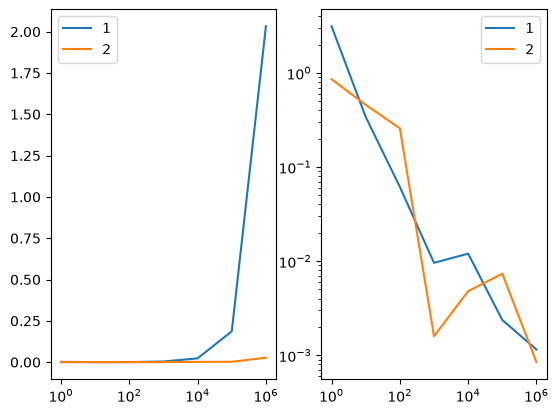

In [49]:
denoms = [1, 10, 100, 1000, 10_000, 100_000, 1_000_000]
mc1_times = []
mc2_times = []

mc1_error = []
mc2_error = []

for i in denoms:
    mc1_times.append(time_monte_carlo(i, monte_carlo_pi))
    mc2_times.append(time_monte_carlo(i, monte_carlo_pi_2))

    mc1_se = np.sqrt((np.pi - monte_carlo_pi(i))**2)
    mc2_se = np.sqrt((np.pi - monte_carlo_pi_2(i))**2)

    mc1_error.append(mc1_se)
    mc2_error.append(mc2_se)

fig, axs = plt.subplots(1, 2)

axs[0].plot(denoms, mc1_times, label='1')
axs[0].plot(denoms, mc2_times, label='2')

axs[0].set_xscale('log')
axs[0].set_xscale('log')

axs[1].plot(denoms, mc1_error, label='1')
axs[1].plot(denoms, mc2_error, label='2')

axs[0].legend()
axs[1].legend()

axs[1].set_xscale('log')
axs[1].set_yscale('log')
print(monte_carlo_pi(denoms[-1]))
print(monte_carlo_pi_2(denoms[-1]))

print(np.pi)

#Monte carlo 2 runs quicker but is less accurate?